In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp

from myutils_corrected_2233 import Ntime, ACFs, set_detectors, set_detector_locations
from myutils_corrected_2233 import ln_likelihood_full_jit, Ntime, ACFs

from scipy.linalg import toeplitz
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data, interp1d_jax, load_tables

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/skyRing/examples/full-sky/../../src/myutils_corrected_2233.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from corner import corner
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tgps = 1242442967.445 + 0.006 
seglen = 8 
fs = 16384 
fmin = 8 
event_id = "GW190521" 
plot_checks = 0 
T = 0.2 
srate = 4096 

ra = 3.5 
dec = 0.73 


factor = 10
seed       = 31567
t0         = 0.0
fmax       = 1500

qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l3/n1l3m3.dat"

tM_shifted_samples_save_dir = "../posterior_files/full-sky/GW190521-t-shift-posteriors/"
tM_shifted_220_samples_save_dir = "../posterior_files/full-sky/GW190521-220-t-shift-posteriors/"

In [4]:
dH1 = TimeSeries.fetch_open_data('H1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)
dL1 = TimeSeries.fetch_open_data('L1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)


n_analyze = Ntime(srate, T)

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo

In [5]:
tH1, tL1

(1242442967.4318974, 1242442967.4302728)

In [6]:
# dH1_cond = bandpass_ds(dH1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)
# dL1_cond = bandpass_ds(dL1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)

In [7]:
nperseg = int(seglen * (1/(dH1.times.value[1] - dH1.times.value[0])))
noverlap = nperseg // 2

psdH = sig.welch(
    dH1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",    
)

psdL = sig.welch(
    dL1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",   
)

In [8]:
dt_np = 1.0 / srate
Nt     = Ntime(srate=srate, T=T)
freqs_np = onp.fft.rfftfreq(Nt, d=dt_np)

fmin_eff = freqs_np[0]  if (fmin is None) else float(fmin)
fmax_eff = freqs_np[-1] if (fmax is None) else float(fmax)

i0 = int(onp.searchsorted(freqs_np, fmin_eff, side="left"))
i1 = int(onp.searchsorted(freqs_np, fmax_eff, side="right"))

freqs = jnp.asarray(freqs_np, dtype=jnp.float64)

# Prior limits
limits = [
    [30.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0, 6.28],
    [-1., 1.],
    [0, 3.14]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [9]:
psdH = interp1d_jax(jnp.asarray(psdH[0],dtype=jnp.float64), jnp.asarray(psdH[1],dtype=jnp.float64))
psdL = interp1d_jax(jnp.asarray(psdL[0],dtype=jnp.float64), jnp.asarray(psdL[1],dtype=jnp.float64))

omega_22_r, omega_22_i, omega_33_r, omega_33_i = load_tables(qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

rhoH, rhoL = ACFs(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
covH=toeplitz(rhoH)
covL=toeplitz(rhoL)
L_H=jnp.linalg.cholesky(covH)
L_L=jnp.linalg.cholesky(covL)

resp_H_py = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].response
resp_L_py = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].response
resp_H = jnp.asarray(resp_H_py, dtype=jnp.float64)
resp_L = jnp.asarray(resp_L_py, dtype=jnp.float64)

set_detectors(resp_H, resp_L)

H1 = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF]
L1 = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF]

rH = jnp.array([H1.location[0], H1.location[1], H1.location[2]], dtype=jnp.float64)
rL = jnp.array([L1.location[0], L1.location[1], L1.location[2]], dtype=jnp.float64)

set_detector_locations(rH, rL)

In [10]:
MTSUN = lal.MTSUN_SI
tM = MTSUN * 325 # Remnant mass peak

In [11]:
num_shifts = 15

t_shifts = []
H1_data_t_shifted = []
L1_data_t_shifted = []

for jj in range(num_shifts):

    dH1_cond = bandpass_ds(dH1, t0=tH1 + (-3 + jj)*1*tM, ds=int(fs/srate), trim=0.25, f_min=fmin)
    dL1_cond = bandpass_ds(dL1, t0=tH1 + (-3 + jj)*1*tM, ds=int(fs/srate), trim=0.25, f_min=fmin)

    dH1_analysis_data = analysis_data(dH1_cond[1], dH1_cond[0], tH1 + (-3 + jj)*1*tM, n_analyze)
    dL1_analysis_data = analysis_data(dL1_cond[1], dL1_cond[0], tH1 + (-3 + jj)*1*tM, n_analyze)

    t_shifts.append((-3 + jj)*1*tM)
    H1_data_t_shifted.append(dH1_analysis_data[1])
    L1_data_t_shifted.append(dL1_analysis_data[1])

In [12]:
onp.savetxt(tM_shifted_samples_save_dir + 't_shifts.txt', t_shifts)

In [13]:
low  = jnp.asarray(low,  dtype=jnp.float64)
high = jnp.asarray(high, dtype=jnp.float64)

In [14]:
logZs = []
for i in range(12,num_shifts):
    h_H_t = H1_data_t_shifted[i]
    h_L_t = L1_data_t_shifted[i]

    def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                    omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                    T, srate, t0):
        def _loglik(theta):
            return ln_likelihood_full_jit(
                dataH=dataH, dataL=dataL, params=theta,
                gmst=gmst, L_H=L_H, L_L=L_L,
                omega_22_r=omega_22_r, omega_22_i=omega_22_i,
                omega_33_r=omega_33_r, omega_33_i=omega_33_i,
                T=T, srate=srate, t0=t0
            )
        return _loglik

    loglik_fn = make_loglik_fn(
        dataH=h_H_t, dataL=h_L_t,
        gmst=gmst, L_H=L_H, L_L=L_L,
        omega_22_r=omega_22_r, omega_22_i=omega_22_i,
        omega_33_r=omega_33_r, omega_33_i=omega_33_i,
        T=T, srate=srate, t0=t0
    )

    def model():
        theta = numpyro.sample("theta", dist.Uniform(low, high).to_event(1))
        numpyro.factor("loglike", loglik_fn(theta))

    rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
    rng_run, rng_post = jax.random.split(rng_key)
    ns = NestedSampler(
        model,
        constructor_kwargs=dict(
            num_live_points=10000,    
            max_samples=500_000,
            verbose=True,
        ),
        termination_kwargs=dict(
            dlogZ=0.01,
        ),
    )
    ns.run(rng_run)
    ns.print_summary()
    posterior = ns.get_samples(rng_post, num_samples=100_000)

    onp.save(tM_shifted_samples_save_dir + 'posterior.' + event_id + '.' + str(i) + '.npy', onp.asarray(posterior['theta']))
    logZs.append(ns._results.log_Z_mean)
    # onp.savetxt(tM_shifted_samples_save_dir + 'logZs.txt', onp.asarray(logZs))


INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 325803
Efficiency: 0.029798396341300017
log(L) contour: -2617.539199116561
log(Z) est.: -831.7412612082217 +- 0.7696310520105809
log(Z | remaining) est.: 1795.639056286925 +- 0.9477727144384889
ESS: 0.6186203997442119

-------
Num samples: 10008
Num likelihood evals: 693754
Efficiency: 0.01884767059514797
log(L) contour: -1284.1453886815061
log(Z) est.: -832.0250623167348 +- 0.6992626192770586
log(Z | remaining) est.: 460.98801791184144 +- 0.7684170048213403
ESS: 0.7928543058822003



INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 325922
Efficiency: 0.029788639955709937
log(L) contour: -2605.134258018042
log(Z) est.: -826.1355896139702 +- 0.8131059570313027
log(Z | remaining) est.: 1788.2934546417018 +- 0.982926842211504
ESS: 0.5335884756217641

-------
Num samples: 10008
Num likelihood evals: 695441
Efficiency: 0.018714272624766493
log(L) contour: -1271.160122906616
log(Z) est.: -825.9616821841471 +- 0.6391050098277091
log(Z | remaining) est.: 453.9448804204678 +- 0.7089098824581022
ESS: 0.9910962382859579

-

INFO:jaxns:Number of Markov-chains set to: 10000


--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 26988367
samples: 175140
phantom samples: 0
likelihood evals / sample: 154.1
phantom fraction (%): 0.0%
--------
logZ=-825.235 +- 0.039
max(logL)=-809.767
H=-10.61
ESS=26242
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 276.0 +- 56.0 | 215.0 / 265.0 / 352.0 | 335.0 | 335.0
theta[1]: 0.45 +- 0.25 | 0.09 / 0.47 / 0.8 | 0.88 | 0.88
theta[2]: 0.79 +- 0.69 | 0.2 / 0.54 / 1.78 | 0.37 | 0.37
theta[3]: 3.3 +- 1.9 | 0.6 / 3.1 / 5.9 | 6.2 | 6.2
theta[4]: 0.21 +- 0.28 | 0.02 / 0.11 / 0.51 | 0.18 | 0.18
theta[5]: 3.2 +- 1.8 | 0.6 / 3.2 / 5.6 | 5.6 | 5.6
theta[6]: -0.02 +- 0.37 | -0.52 / -0.01 / 0.44 | 0.33 | 0.33
theta[7]: 3.9 +- 1.6 | 1.9 / 4.3 / 5.8 | 5.2 | 5.2
theta[8]: -0.07 +- 0.6 | -0.83 / -0.19 / 0.77 | 0.78 | 0.78
theta[9]: 1.56 +- 0.92 | 0.33 / 1.52 / 2.85 | 2.65 | 2.65
--------
Running over 12 devices.
Creating initial state with 10008 live points.
Runn

In [15]:
logZs

[Array(-826.42770219, dtype=float64),
 Array(-828.71968139, dtype=float64),
 Array(-825.897969, dtype=float64),
 Array(-824.32744898, dtype=float64),
 Array(-820.56121277, dtype=float64),
 Array(-820.88758286, dtype=float64),
 Array(-822.88866961, dtype=float64),
 Array(-829.41858349, dtype=float64),
 Array(-824.306789, dtype=float64),
 Array(-827.12706913, dtype=float64),
 Array(-827.62131667, dtype=float64),
 Array(-828.41977291, dtype=float64)]

In [15]:
logZs


[Array(-828.84832836, dtype=float64),
 Array(-825.23520998, dtype=float64),
 Array(-822.33437245, dtype=float64)]

In [16]:
limits = [
    [30.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0, 6.28],
    [-1., 1.],
    [0, 3.14]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [17]:
low  = jnp.asarray(low,  dtype=jnp.float64)
high = jnp.asarray(high, dtype=jnp.float64)

In [18]:
logZs_220 = []
for i in range(12, num_shifts):
    h_H_t = H1_data_t_shifted[i]
    h_L_t = L1_data_t_shifted[i]

    def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                    omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                    T, srate, t0):
        def _loglik(theta):
            return ln_likelihood_full_jit(
                dataH=dataH, dataL=dataL, params=theta,
                gmst=gmst, L_H=L_H, L_L=L_L,
                omega_22_r=omega_22_r, omega_22_i=omega_22_i,
                omega_33_r=omega_33_r, omega_33_i=omega_33_i,
                T=T, srate=srate, t0=t0
            )
        return _loglik

    loglik_fn = make_loglik_fn(
        dataH=h_H_t, dataL=h_L_t,
        gmst=gmst, L_H=L_H, L_L=L_L,
        omega_22_r=omega_22_r, omega_22_i=omega_22_i,
        omega_33_r=omega_33_r, omega_33_i=omega_33_i,
        T=T, srate=srate, t0=t0
    )

    def model_220():
        theta = numpyro.sample("theta", dist.Uniform(low, high).to_event(1))
        amp_phase_330 = jnp.array([0.0, 0.0])
        theta_ = jnp.concatenate(
                            [
                                theta[:4],
                                amp_phase_330,
                                theta[4:],
                            ],
                        )

        numpyro.factor("loglike", loglik_fn(theta_))

    rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
    rng_run, rng_post = jax.random.split(rng_key)
    ns = NestedSampler(
        model_220,
        constructor_kwargs=dict(
            num_live_points=10000,    
            max_samples=500_000,
            verbose=True,
        ),
        termination_kwargs=dict(
            dlogZ=0.01,
        ),
    )
    ns.run(rng_run)
    ns.print_summary()
    posterior = ns.get_samples(rng_post, num_samples=100_000)

    onp.save(tM_shifted_220_samples_save_dir + 'posterior.' + event_id + '.' + str(i) + '.npy', onp.asarray(posterior['theta']))
    logZs_220.append(ns._results.log_Z_mean)
    # onp.savetxt(tM_shifted_220_samples_save_dir + 'logZs_220.txt', onp.asarray(logZs_220))


INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 242537
Efficiency: 0.040429666196710845
log(L) contour: -1439.7373160328057
log(Z) est.: -828.5719266068294 +- 0.5770893422624617
log(Z | remaining) est.: 620.575523481638 +- 0.7575901408267438
ESS: 1.2650475838248245

-------
Num samples: 10008
Num likelihood evals: 518633
Efficiency: 0.02519060336126416
log(L) contour: -937.570603595162
log(Z) est.: -827.4665489053456 +- 0.5655642384156527
log(Z | remaining) est.: 117.18098006443233 +- 0.5846046777441084
ESS: 1.3264746150253406

--

INFO:jaxns:Number of Markov-chains set to: 10000


--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 21606621
samples: 150120
phantom samples: 0
likelihood evals / sample: 143.9
phantom fraction (%): 0.0%
--------
logZ=-826.464 +- 0.037
max(logL)=-814.398
H=-9.31
ESS=20839
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 260.0 +- 39.0 | 213.0 / 256.0 / 315.0 | 288.0 | 288.0
theta[1]: 0.51 +- 0.24 | 0.16 / 0.54 / 0.81 | 0.74 | 0.74
theta[2]: 0.5 +- 0.49 | 0.16 / 0.34 / 1.02 | 0.21 | 0.21
theta[3]: 3.3 +- 1.8 | 0.9 / 3.2 / 5.7 | 0.3 | 0.3
theta[4]: -0.06 +- 0.5 | -0.73 / -0.08 / 0.65 | -1.0 | -1.0
theta[5]: 3.6 +- 1.7 | 1.3 / 3.5 / 5.9 | 5.3 | 5.3
theta[6]: -0.03 +- 0.59 | -0.85 / -0.05 / 0.77 | 0.36 | 0.36
theta[7]: 1.5 +- 0.9 | 0.29 / 1.46 / 2.75 | 0.05 | 0.05
--------
Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondi

INFO:jaxns:Number of Markov-chains set to: 10000


--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 20055592
samples: 145116
phantom samples: 0
likelihood evals / sample: 138.2
phantom fraction (%): 0.0%
--------
logZ=-822.837 +- 0.036
max(logL)=-811.345
H=-8.64
ESS=21493
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 264.0 +- 42.0 | 215.0 / 258.0 / 322.0 | 283.0 | 283.0
theta[1]: 0.49 +- 0.25 | 0.13 / 0.51 / 0.8 | 0.7 | 0.7
theta[2]: 0.5 +- 0.5 | 0.15 / 0.34 / 0.99 | 0.33 | 0.33
theta[3]: 3.4 +- 1.9 | 0.6 / 3.2 / 5.9 | 2.7 | 2.7
theta[4]: -0.04 +- 0.49 | -0.71 / -0.05 / 0.66 | 0.75 | 0.75
theta[5]: 3.6 +- 1.8 | 1.3 / 3.5 / 5.8 | 5.3 | 5.3
theta[6]: -0.08 +- 0.61 | -0.88 / -0.12 / 0.77 | 0.81 | 0.81
theta[7]: 1.58 +- 0.9 | 0.34 / 1.6 / 2.82 | 1.44 | 1.44
--------
Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationConditio

INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode


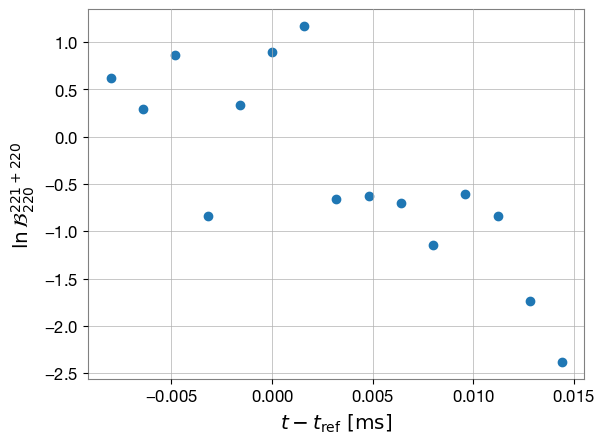

In [20]:
plt.scatter(t_shifts, onp.array(logZs) - onp.array(logZs_220))
plt.xlabel(r'$t - t_{\mathrm{ref}}\ \mathrm{[ms]}$')
plt.ylabel(r'$\ln \mathcal{B}^{221+220}_{220}$')
plt.show()

INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode


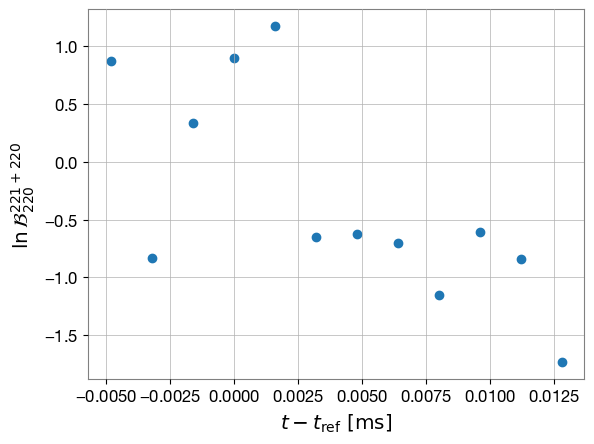

In [19]:
plt.scatter(t_shifts, onp.array(logZs) - onp.array(logZs_220))
plt.xlabel(r'$t - t_{\mathrm{ref}}\ \mathrm{[ms]}$')
plt.ylabel(r'$\ln \mathcal{B}^{221+220}_{220}$')
plt.show()